- Blood_fat.csv 파일을 활용하여 다중 선형 회귀
- 몸무게와 나이를 입력받아 혈중 지방 함량을 예측하는 모델
- 파일에 몸무게 나이 혈중 지방 함량 순서 

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import mat_kor

data = np.loadtxt("Data/Blood_fat.csv", delimiter = ",", dtype=np.float64)

x1 = tf.constant(data[:, 0], dtype=tf.float64) #체중
x2 = tf.constant(data[:, 1], dtype=tf.float64) #나이
y = tf.constant(data[:, 2], dtype=tf.float64) #혈중 지방

w1 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed = 0))
w2 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed = 0))
b = tf.Variable(tf.random.uniform([1], 0, 100, dtype=tf.float64, seed = 0))

def hypothesis(w1, w2 ,b):
    return x1 * w1 + x2 * w2 + b
def cost(w1, w2, b):
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(w1, w2 ,b) - y)))

opt = tf.keras.optimizers.SGD(learning_rate = 0.001)
epochs = 5001

for i in range(5001):
    #자동 미분을 위한 테이프
    with tf.GradientTape() as tape:
        current_cost = cost(w1, w2, b) #기록할 내용이 w, b임을 명시
    gradients = tape.gradient(current_cost, [w1, w2, b]) #손실에 대한 w, b의 미분값 계산
    opt.apply_gradients(zip(gradients, [w1, w2, b])) #미분값으로 w와 b를 업데이트 (조정)
    if i % 100 == 0:
        print(i, f'{current_cost.numpy()}, {w1.numpy()}, {w2.numpy()}, {b.numpy()}')

0 579.8910245142281, [7.99948474], [7.7921178], [18.52939248]
100 45.41474237804826, [1.81858573], [4.38207256], [18.44364284]
200 43.996090811869976, [1.60566912], [4.61357998], [18.44613521]
300 43.41569622961187, [1.48650464], [4.82167379], [18.44964724]
400 43.068077336628924, [1.3943015], [4.98266316], [18.45327794]
500 42.86254819635756, [1.32341485], [5.1064104], [18.45699489]
600 42.74196474969345, [1.26912714], [5.20115769], [18.46077446]
700 42.67152660449445, [1.22764613], [5.27353051], [18.46459961]
800 42.63046825614693, [1.19599181], [5.32873526], [18.46845812]
900 42.606547139625626, [1.17185323], [5.37080936], [18.47234118]
1000 42.59259624729495, [1.15345204], [5.40285978], [18.47624238]
1100 42.58443713062143, [1.13942584], [5.42726675], [18.48015704]
1200 42.57963953739357, [1.1287336], [5.44584902], [18.48408174]
1300 42.57679196219261, [1.12058107], [5.45999423], [18.4880139]
1400 42.575075257392015, [1.11436278], [5.47076019], [18.49195164]
1500 42.574014265606735

In [2]:
print("w1 =", w1.numpy())
print("w2 =", w2.numpy())
print("b =", b.numpy())

#예측 (첫 25개의 샘플)
y_pred = (w1*x1[:25]+ w2*x2[:25]+b).numpy()
print(y_pred)

w1 = [1.09304688]
w2 = [5.50448122]
b = [18.63414349]
[363.6562177  208.51619034 375.91521421 260.28186186 415.46113601
 231.66640889 241.62157124 295.49484293 418.74027666 342.80983331
 180.25395855 286.55423387 375.91521421 207.54088385 413.39278264
 358.26947687 271.36931789 385.71338936 375.83672061 295.41634933
 336.3300456  218.47135269 315.20893363 298.93097077 252.63053367]


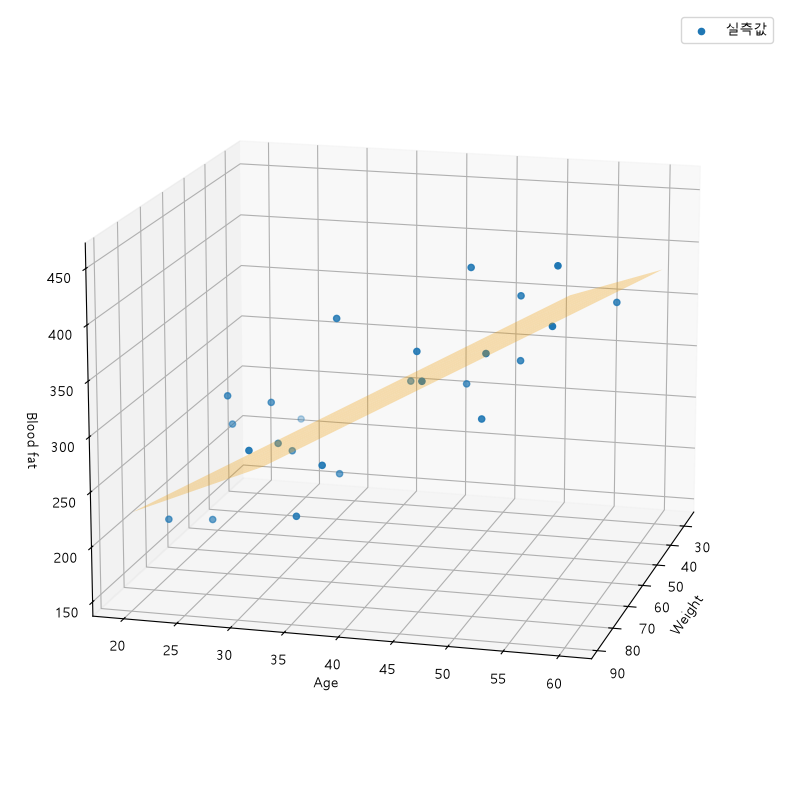

In [3]:
#3D 산점도 시각화
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y, label = "실측값")
ax.set_xlabel("Weight")
ax.set_ylabel("Age")
ax.set_zlabel("Blood fat")

w_grid = np.linspace(min(x1), max(x1), 10)
a_grid = np.linspace(min(x2), max(x2), 10)
W, A = np.meshgrid(w_grid, a_grid)
B_pred = w1.numpy() * W + w2.numpy() * A + b.numpy()
ax.plot_surface(W, A, B_pred, alpha = 0.3, color="orange")

ax.view_init(15, 15)
plt.legend()
plt.show()


로지스틱 회귀
- 선형 회귀는 연속적인 값 예측
- 로지스틱 회귀는 참, 거짓 둘 중 결과 판단할 때 사용
- 미분 불가능 또는 기울기 0 -> 경사하강법 사용 불가
- y = 1 / (1 + e^-(ax+b)) 형태의 sigmoid 함수 사용
- a는 그래프의 경사도, 즉 변화의 급격함을 결정
- a값이 커지면 그래프가 가파르고 작아지면 완만하게 변함
- b는 좌우로 이동하는 값을 결정
- b값이 커지면 그래프가 오른쪽, 작아지면 왼쪽으로 이동
- a,b값이 너무 크면 그래프가 데이터 점들과 잘 맞지 않아 오차가 커짐